# RRN Footprint Performance Visualization

This notebook visualizes the performance benchmark results from RRN testing, comparing:
- **Geometries**: Circle, Quad (quadrilateral), Poly16 (16-sided polygon)
- **Methods**: Default (STCS overlay only) vs. add_table (table markers + STCS overlay)
- **Metrics**: Wall time and peak memory usage across different numbers of sources

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [18]:
df = pd.read_csv('footprint_geometry_performance_results.csv')
df.head()

,count,shape,method,peak_memory_mib,memory_increment_mib,cpu_user_seconds,cpu_system_seconds,cpu_total_seconds,wall_time_seconds
0,100,poly16,stcs_only,397.12,0.00,0.231,0.0302,0.261,0.421
1,100,poly16,add_table,398.12,0.01,0.180,0.0488,0.229,0.386
2,1000,poly16,stcs_only,398.54,0.00,0.188,0.0169,0.205,0.363
3,1000,poly16,add_table,400.41,0.00,0.211,0.0512,0.262,0.381
4,10000,poly16,stcs_only,415.64,0.00,0.208,0.0587,0.267,0.387


In [ ]:
shapes = ['circle', 'square', 'poly16']
methods = ['stcs_only', 'add_table']
metrics = ['wall_time_seconds', 'cpu_total_seconds', 'peak_memory_mib']

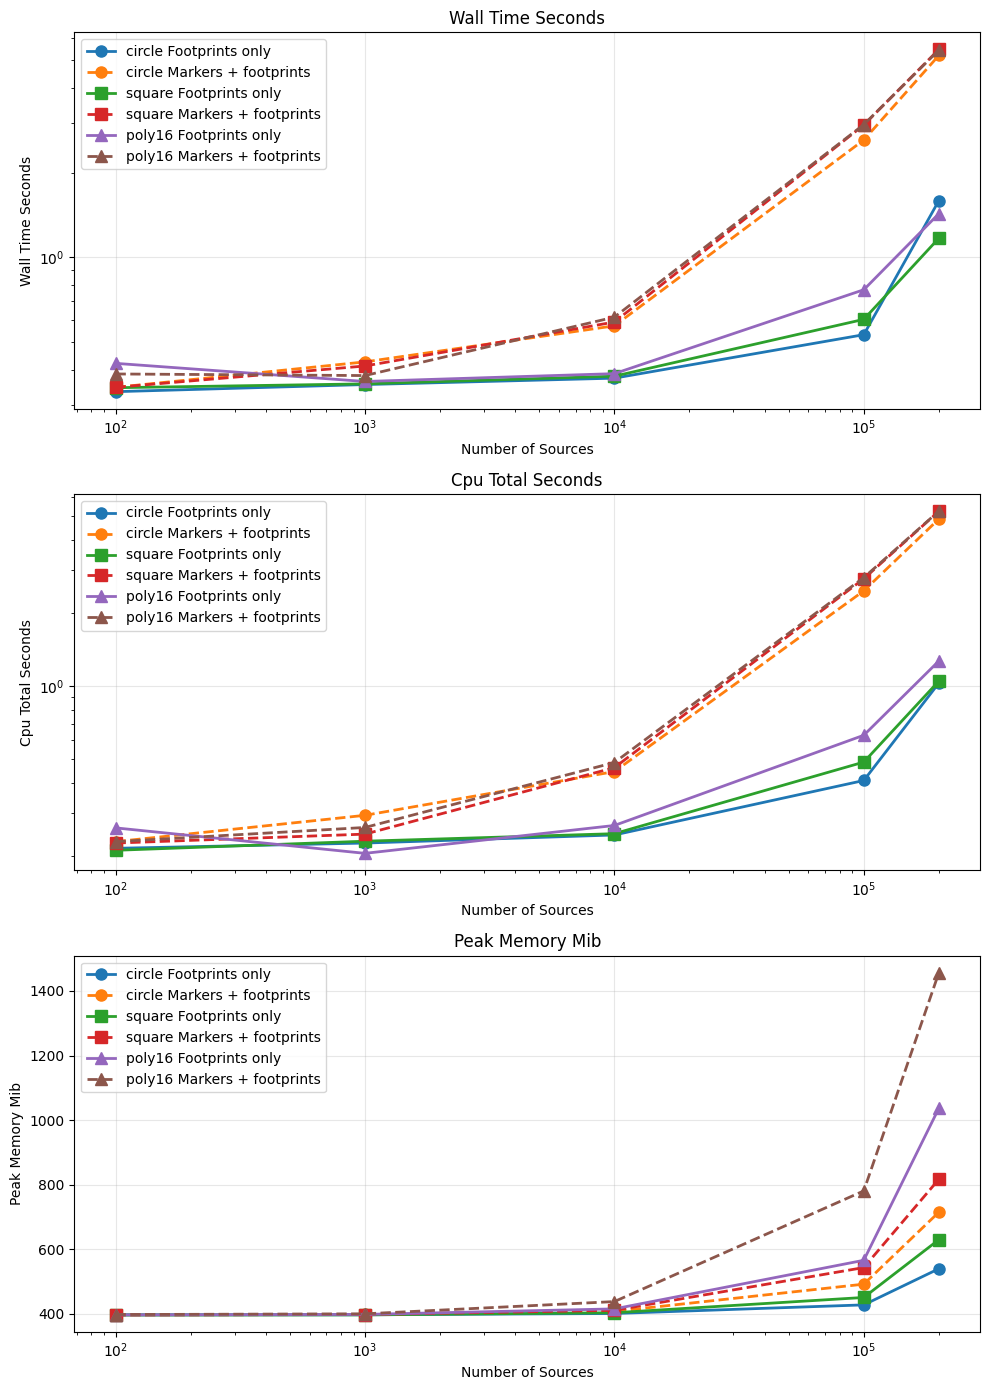

In [ ]:
method_labels = {
    'stcs_only': 'Footprints only',
    'add_table': 'Markers + footprints'
}

fig, axs = plt.subplots(len(metrics), 1, figsize=(10, 14))

for i, metric in enumerate(metrics):
    for shape, marker in [('circle', 'o'), ('square', 's'), ('poly16', '^')]:
        for method, ls in [('stcs_only', '-'), ('add_table', '--')]:
            data = df[(df['shape'] == shape) & (df['method'] == method)].sort_values('count')
            
            label = f'{shape} {method_labels[method]}'
            axs[i].plot(data['count'], data[metric], 
                       marker=marker, linestyle=ls, label=label, linewidth=2, markersize=8)
    
    axs[i].legend(loc="upper left")
    axs[i].set_title(metric.replace('_', ' ').title())
    axs[i].set_xlabel("Number of Sources")
    axs[i].set_ylabel(metric.replace('_', ' ').title())
    axs[i].grid(True, alpha=0.3)
    axs[i].set_xscale('log')
    if metric in ['wall_time_seconds', 'cpu_total_seconds']:
        axs[i].set_yscale('log')

plt.tight_layout()
plt.savefig("footprint_geometry_performance_plot.png", dpi=300)
plt.show()